# 03 — CNN Feature Extraction
Use a **frozen MobileNetV2** (pretrained on ImageNet) to extract 1280-d feature vectors for each of the 100 paired images, then map vectors back to all tabular rows.

## 3.1 — Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from cnn_extractor import (
    get_device, get_transforms, load_extractor,
    extract_features, save_features
)

np.random.seed(42)
torch.manual_seed(42)
print("Setup complete.")

Setup complete.


## 3.2 — Device Check

In [2]:
device = get_device()

[get_device] Using device: cpu


## 3.3 — Load Pairing CSV

In [3]:
df_pair = pd.read_csv("../data/processed/pairing.csv")
print(f"Total rows in pairing: {len(df_pair)}")
df_pair.head()

Total rows in pairing: 1460


,row_idx,OverallQual,image_path
0,0,7,../data/raw/images\Dinning\din_754.jpg
1,1,6,../data/raw/images\Dinning\din_151.jpg
2,2,7,../data/raw/images\Dinning\din_880.jpg
3,3,7,../data/raw/images\Dinning\din_915.jpg
4,4,8,../data/raw/images\Kitchen\kitchen_1327.jpg


## 3.4 — Extract Features for the 100 Unique Images
We extract features only once per unique image, then broadcast to all rows.  
This avoids re-running the CNN ~1400× for the same 100 images.

In [4]:
# Get unique images in a stable order
unique_paths = df_pair["image_path"].unique().tolist()
print(f"Unique images to process: {len(unique_paths)}")

transform    = get_transforms(size=128)
extractor    = load_extractor(device)

unique_features = extract_features(
    image_paths=unique_paths,
    model=extractor,
    transform=transform,
    device=device,
    batch_size=16
)
print(f"Unique features shape: {unique_features.shape}")

Unique images to process: 85
[load_extractor] MobileNetV2 extractor ready (frozen backbone)


Extracting CNN features: 100%|██████████| 6/6 [00:02<00:00,  2.30it/s]

[extract_features] Extracted features shape: (85, 1280)
Unique features shape: (85, 1280)


## 3.5 — Build Path → Feature Index Map

In [5]:
path_to_idx = {p: i for i, p in enumerate(unique_paths)}
print(f"Mapping built: {len(path_to_idx)} entries")

Mapping built: 85 entries


## 3.6 — Broadcast Features to All Rows

In [6]:
row_indices = df_pair["image_path"].map(path_to_idx).values  # (N,)
image_features_all = unique_features[row_indices]            # (N, 1280)

print(f"Final image features shape (all rows): {image_features_all.shape}")

# Quick sanity check: first row should match the first unique image
assert np.allclose(
    image_features_all[0],
    unique_features[path_to_idx[df_pair.iloc[0]["image_path"]]]
), "Mapping sanity check failed!"
print("Sanity check passed.")

Final image features shape (all rows): (1460, 1280)
Sanity check passed.


## 3.7 — Verify Feature Statistics

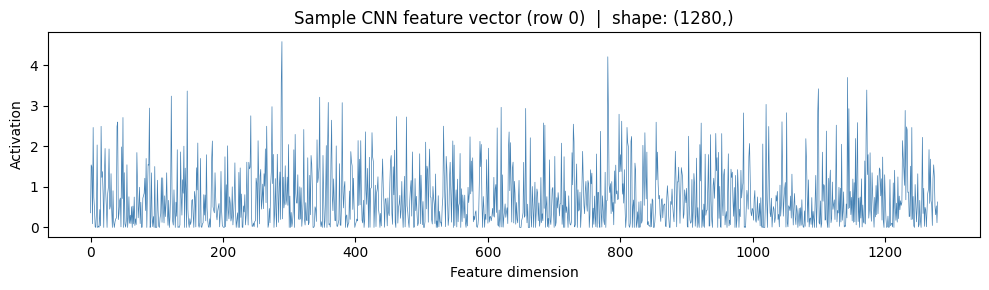

Mean activation : 0.7094
Std  activation : 0.8014
Min / Max       : 0.0000 / 4.9495


In [7]:
fig, ax = plt.subplots(figsize=(10, 3))
sample_vec = image_features_all[0]
ax.plot(sample_vec, linewidth=0.5, color="steelblue")
ax.set_title("Sample CNN feature vector (row 0)  |  shape: (1280,)")
ax.set_xlabel("Feature dimension")
ax.set_ylabel("Activation")
plt.tight_layout()
plt.savefig("../outputs/plots/sample_cnn_vector.png", dpi=120)
plt.show()

print(f"Mean activation : {image_features_all.mean():.4f}")
print(f"Std  activation : {image_features_all.std():.4f}")
print(f"Min / Max       : {image_features_all.min():.4f} / {image_features_all.max():.4f}")

## 3.8 — Save Features

In [8]:
os.makedirs("../outputs/features", exist_ok=True)

save_features(image_features_all, "../outputs/features/image_features.npy")
np.save("../outputs/features/unique_image_features.npy", unique_features)

print("Image features saved successfully.")

[save_features] Saved (1460, 1280) → '../outputs/features/image_features.npy'  (7.48 MB)
Image features saved successfully.
